In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df=sns.load_dataset('healthexp')
df.head(10)

,Year,Country,Spending_USD,Life_Expectancy
0,1970,Germany,252.311,70.6
1,1970,France,192.143,72.2
2,1970,Great Britain,123.993,71.9
3,1970,Japan,150.437,72.0
4,1970,USA,326.961,70.9
5,1971,Canada,313.391,72.8
6,1971,Germany,298.251,70.8
7,1971,Great Britain,134.172,71.9
8,1971,Japan,163.854,72.9
9,1971,USA,357.988,71.2


In [4]:
df.shape

(274, 4)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 274 entries, 0 to 273
Data columns (total 4 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Year             274 non-null    int64  
 1   Country          274 non-null    object 
 2   Spending_USD     274 non-null    float64
 3   Life_Expectancy  274 non-null    float64
dtypes: float64(2), int64(1), object(1)
memory usage: 8.7+ KB


In [6]:
df.isnull().sum()

Year               0
Country            0
Spending_USD       0
Life_Expectancy    0
dtype: int64

In [7]:
df.duplicated().sum()

np.int64(0)

---
#### 1- Déterminez quelles sont les variables Discrètes et Continues du dataset

In [8]:
df.head(10)

,Year,Country,Spending_USD,Life_Expectancy
0,1970,Germany,252.311,70.6
1,1970,France,192.143,72.2
2,1970,Great Britain,123.993,71.9
3,1970,Japan,150.437,72.0
4,1970,USA,326.961,70.9
5,1971,Canada,313.391,72.8
6,1971,Germany,298.251,70.8
7,1971,Great Britain,134.172,71.9
8,1971,Japan,163.854,72.9
9,1971,USA,357.988,71.2


In [9]:
# Vérification par le type de données
df.dtypes

Year                 int64
Country             object
Spending_USD       float64
Life_Expectancy    float64
dtype: object


##### 'Country' = variable Discrète
##### 'Year' = variable  Discrète
##### 'Spending_USD' = variable Continue
##### 'Life_Expectancy' = variable Continue

---
#### 2- Analyse de la variable "Country"

In [10]:
df['Year'].unique()

array([1970, 1971, 1972, 1973, 1974, 1975, 1976, 1977, 1978, 1979, 1980,
       1981, 1982, 1983, 1984, 1985, 1986, 1987, 1988, 1989, 1990, 1991,
       1992, 1993, 1994, 1995, 1996, 1997, 1998, 1999, 2000, 2001, 2002,
       2003, 2004, 2005, 2006, 2007, 2008, 2009, 2010, 2011, 2012, 2013,
       2014, 2015, 2016, 2017, 2018, 2019, 2020])

In [11]:
df['Country'].value_counts()

Country
Japan            51
USA              51
Germany          50
Canada           44
Great Britain    43
France           35
Name: count, dtype: int64

In [12]:
print(f'Nombres de Pays est:',df['Country'].nunique())

Nombres de Pays est: 6


In [13]:
print(plt.style.available)

['Solarize_Light2', '_classic_test_patch', '_mpl-gallery', '_mpl-gallery-nogrid', 'bmh', 'classic', 'dark_background', 'fast', 'fivethirtyeight', 'ggplot', 'grayscale', 'petroff10', 'seaborn-v0_8', 'seaborn-v0_8-bright', 'seaborn-v0_8-colorblind', 'seaborn-v0_8-dark', 'seaborn-v0_8-dark-palette', 'seaborn-v0_8-darkgrid', 'seaborn-v0_8-deep', 'seaborn-v0_8-muted', 'seaborn-v0_8-notebook', 'seaborn-v0_8-paper', 'seaborn-v0_8-pastel', 'seaborn-v0_8-poster', 'seaborn-v0_8-talk', 'seaborn-v0_8-ticks', 'seaborn-v0_8-white', 'seaborn-v0_8-whitegrid', 'tableau-colorblind10']


Text(0.5, 1.0, 'Nombres de Pays')

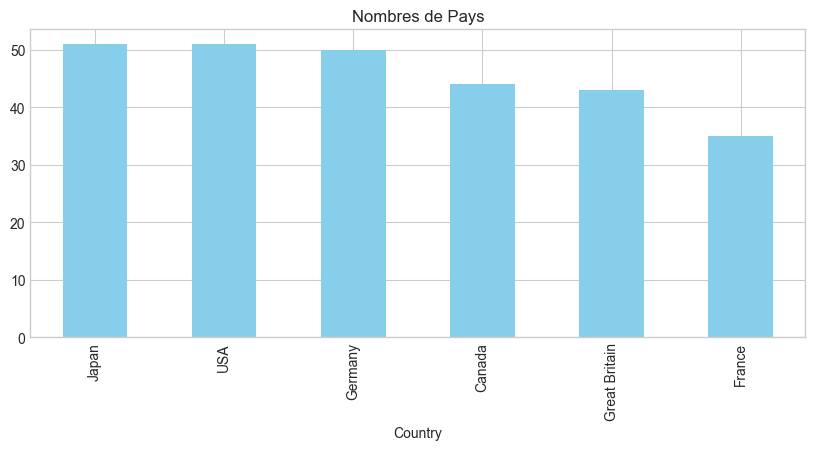

In [14]:
plt.figure(figsize=(10, 4))
plt.style.use('seaborn-v0_8-whitegrid')
df['Country'].value_counts().plot(kind="bar", color='skyblue')
plt.title("Nombres de Pays")

Interprétation : Le dataset est équilibré. Chaque pays (Japan, USA, Germany, Canada, Great Britain, France) possède environ 45 à 50 entrées, ce qui permet une comparaison fiable sur la période 1970-2020.

 3-Analyse de "Spending_USD" et interprétation de la moyenne

In [15]:
mean_spending = df['Spending_USD'].mean()
print(f"La moyenne des dépenses : {mean_spending:.2f} USD")

La moyenne des dépenses : 2789.34 USD


Interprétation : La valeur de 2789.34  USD représente la dépense annuelle moyenne de santé par habitant, calculée sur l'ensemble des pays du dataset pour la période allant de 1970 à 2020

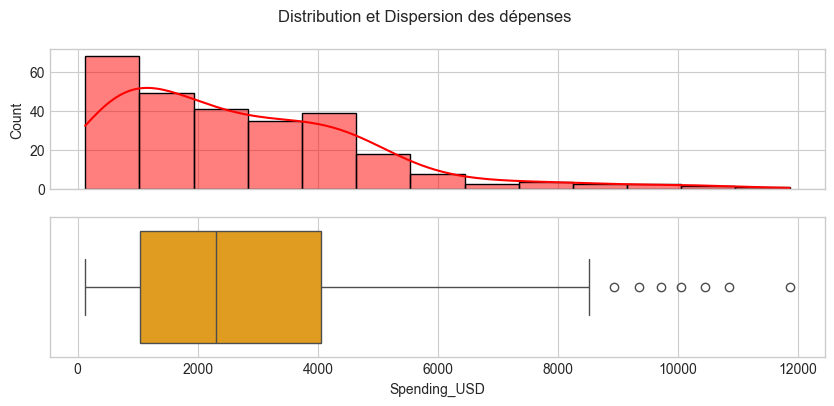

In [16]:
fig, ax = plt.subplots(2, 1, sharex=True,figsize=(10, 4))

plt.suptitle("Distribution et Dispersion des dépenses")
sns.histplot(data=df, x='Spending_USD', kde=True, color='red',ax=ax[0])
sns.boxplot(data=df,  x='Spending_USD', color='orange',ax=ax[1])
plt.show()


Interprétation : La distribution est étirée vers la droite. La boxplot révèle des valeurs très élevées qui s'éloignent de la médiane, suggérant des disparités massives entre les pays.

4-Analysez la variable "Life_Expectancy".

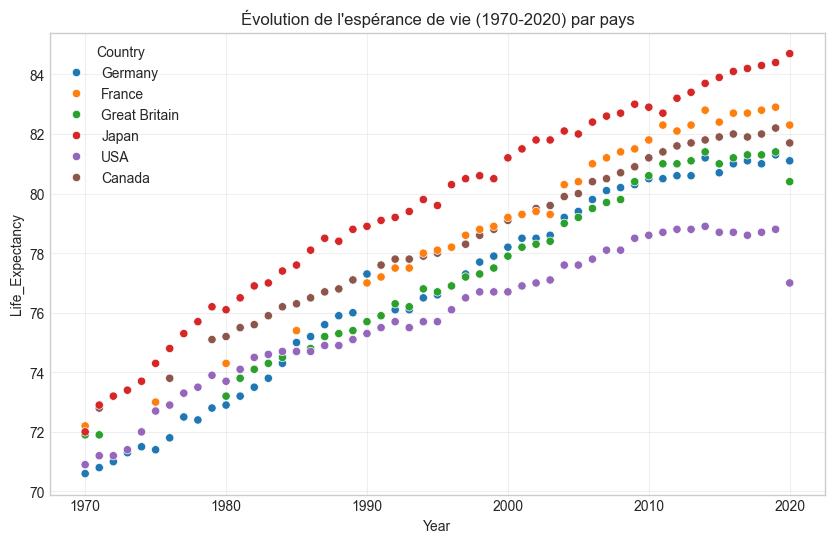

In [17]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df,x='Year', y='Life_Expectancy', hue='Country')
plt.title("Évolution de l'espérance de vie (1970-2020) par pays")
plt.grid(True, alpha=0.3)
plt.show()

5-l'évolution de la durée de vie à travers le temps.

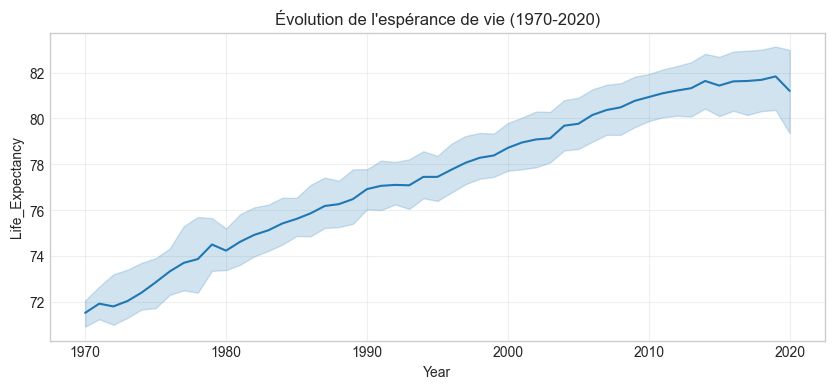

In [18]:
plt.figure(figsize=(10, 4))
sns.lineplot(data=df,x='Year', y='Life_Expectancy')
plt.title("Évolution de l'espérance de vie (1970-2020)")
plt.grid(True, alpha=0.3)
plt.show()

Interprétation : On remarque l'augmentation de la durée de vie à travers le temps, mais avec une diminution de 2019 à 2020, ce qu'on peut lier à la période de Covid-19.

6-Les dépenses en santé de l'Allemagne et de la Grande Bretagne à travers le temps.

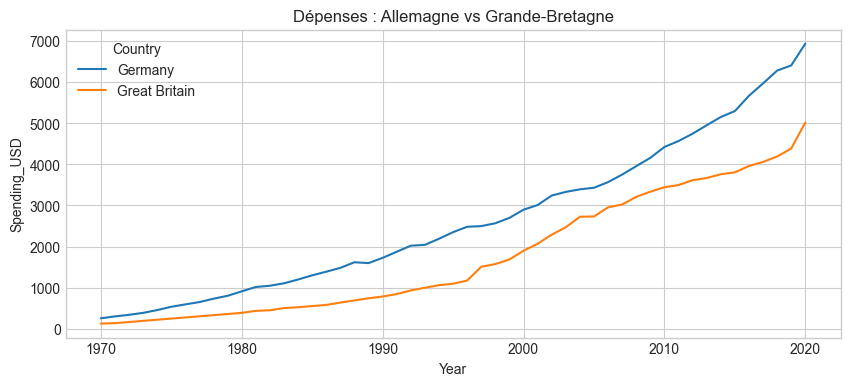

In [19]:
plt.figure(figsize=(10, 4))
countries_compare = df[df['Country'].isin(['Germany', 'Great Britain'])]
sns.lineplot(x='Year', y='Spending_USD', hue='Country', data=countries_compare)
plt.title("Dépenses : Allemagne vs Grande-Bretagne")
plt.show()

Interprétation : Bien que les deux pays suivent une courbe ascendante, l'Allemagne a commencé à décrocher de la Grande-Bretagne dans les années 90, investissant nettement plus par habitant.

7-Observation de l'histogramme, la boxplot, et les statistiques de "Life_Expectancy" propre à chaque pays.

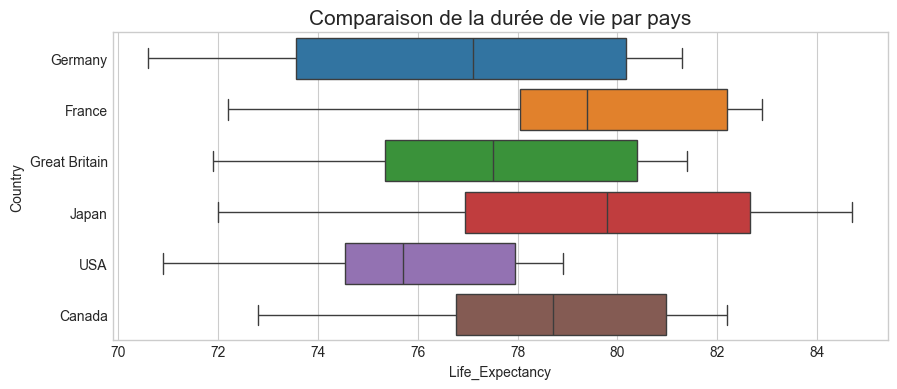

In [20]:
plt.figure(figsize=(10, 4))
sns.boxplot(data=df, x='Life_Expectancy', y='Country',hue='Country')
plt.title("Comparaison de la durée de vie par pays", fontsize=15)
plt.show()

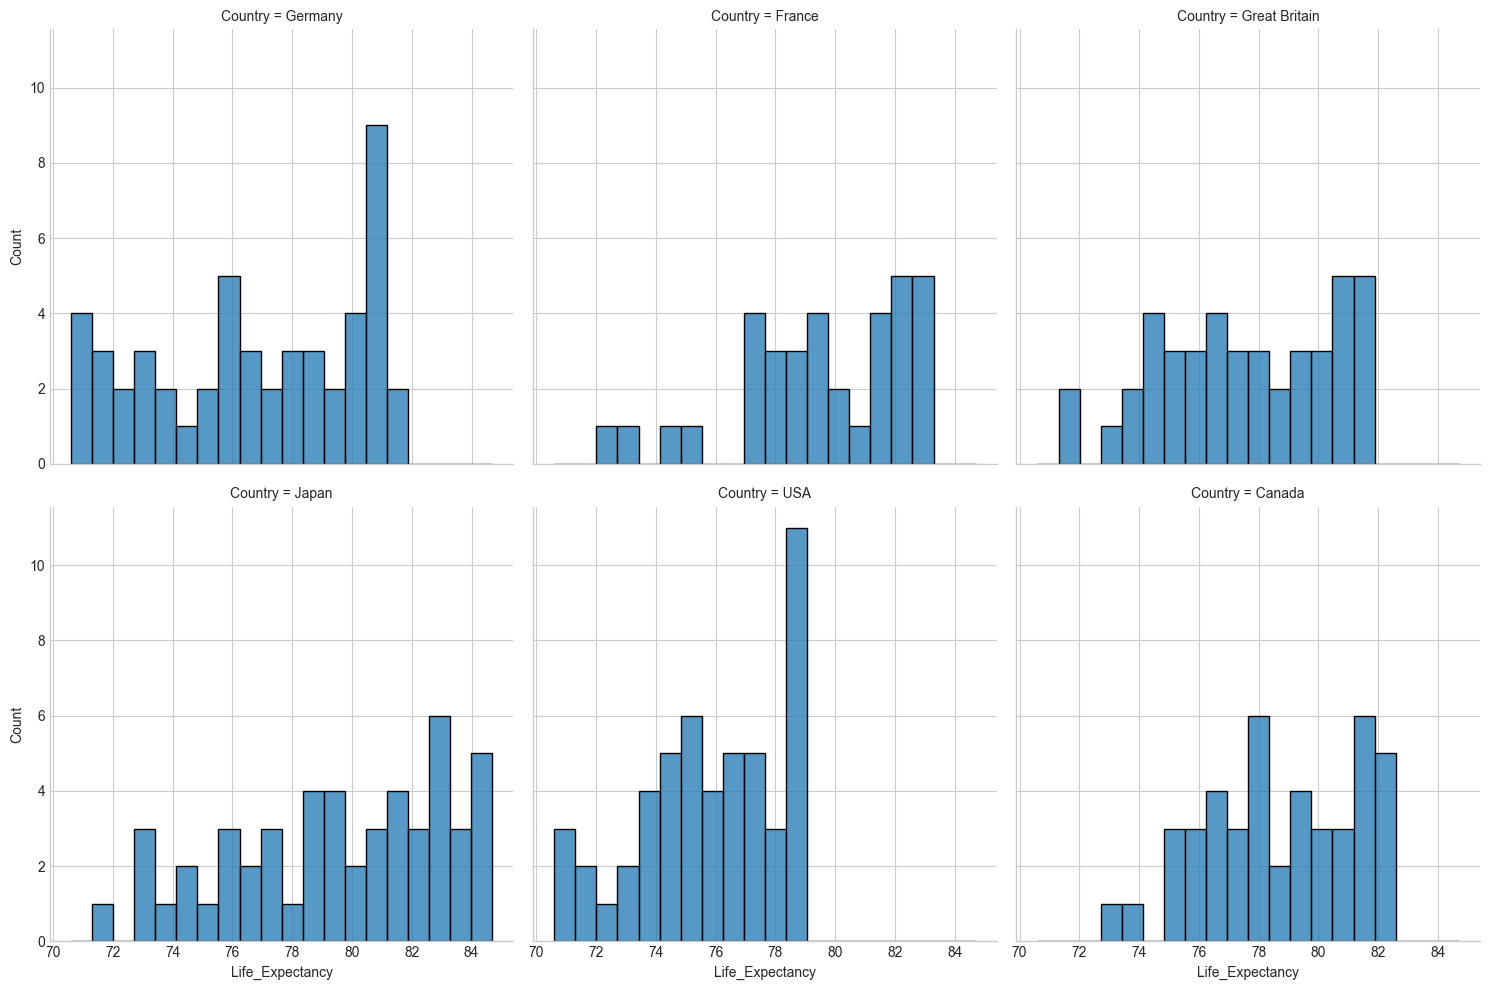

In [21]:

sns.displot(data=df, x='Life_Expectancy', col='Country',col_wrap=3,bins=20)
plt.show()

Interprétation : le Japan à une grande durée de vie (82 ans et plus) suivi de la France  puis canada

8-La relation Durée de vie vs Dépenses en USA durant 2000-2020

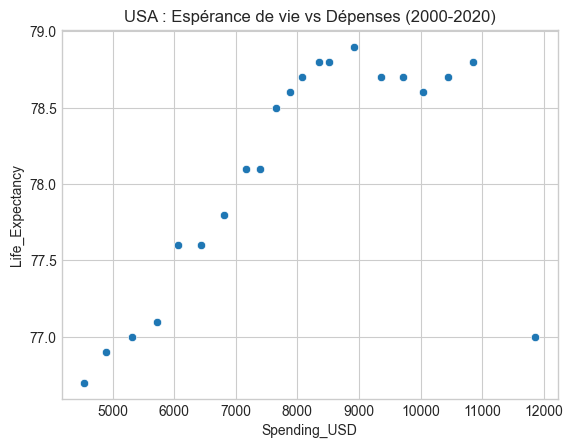

In [22]:
usa_2020 = df[(df['Country'] == 'USA') & (df['Year'] >= 2000)]
sns.scatterplot(x='Spending_USD', y='Life_Expectancy', data=usa_2020)
plt.title("USA : Espérance de vie vs Dépenses (2000-2020)")
plt.show()

Interprétation= Nous observons une correlation entre Espérance de vie et Dépenses dans l'USA , aussi on remarque une valeur 